In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from scipy import stats
from scipy.stats import pearsonr
 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
 
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10



**PREPROCESSING STEP 1 & 2: Load & Verify**

In [2]:
df = pd.read_csv("patient_vitals.csv", parse_dates=["Timestamp"])
 
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
 
# Verify critical columns
critical = ["PatientID", "Timestamp", "Diagnosis"]
for col in critical:
    nulls = df[col].isnull().sum()
    print(f"  {col}: {nulls} nulls — {'OK' if nulls == 0 else 'ANOMALY'}")
 
print("\nSample rows:")
df.head(3)


Shape: (60000, 13)

Dtypes:
 PatientID                         object
Timestamp                 datetime64[ns]
HeartRate                        float64
BloodPressureSystolic            float64
BloodPressureDiastolic           float64
BloodOxygenLevel                 float64
BodyTemperature                  float64
RespiratoryRate                  float64
SleepHours                       float64
StressLevel                        int64
Age                                int64
Gender                            object
Diagnosis                         object
dtype: object

Null counts:
 PatientID                 0
Timestamp                 0
HeartRate                 0
BloodPressureSystolic     0
BloodPressureDiastolic    0
BloodOxygenLevel          0
BodyTemperature           0
RespiratoryRate           0
SleepHours                0
StressLevel               0
Age                       0
Gender                    0
Diagnosis                 0
dtype: int64
  PatientID: 0 nulls — OK
  Time

,PatientID,Timestamp,HeartRate,BloodPressureSystolic,BloodPressureDiastolic,BloodOxygenLevel,BodyTemperature,RespiratoryRate,SleepHours,StressLevel,Age,Gender,Diagnosis
0,P0001,2024-01-01 00:00:00,83.2,153.9,90.6,96.3,36.58,16.0,6.2,6,38,M,Hypertension
1,P0001,2024-01-01 06:00:00,81.2,172.5,110.3,95.0,36.88,16.5,5.8,3,38,M,Hypertension
2,P0001,2024-01-01 12:00:00,94.9,154.7,100.8,97.3,36.95,16.4,6.0,6,38,M,Hypertension


**PREPROCESSING STEP 3: Physiological Range Filters**

In [3]:
physiological_bounds = {
    "HeartRate":               (40,  180),
    "BloodPressureSystolic":   (80,  200),
    "BloodPressureDiastolic":  (50,  130),
    "BloodOxygenLevel":        (85,  100),
    "BodyTemperature":         (35.5, 41.0),
    "RespiratoryRate":         (10,   40),
    "SleepHours":              (2,   12),
    "StressLevel":             (1,   10),
}
 
rows_before = len(df)
drop_report = {}
 
for col, (lo, hi) in physiological_bounds.items():
    before = len(df)
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    dropped = before - len(df)
    drop_report[col] = dropped
 
print("Rows dropped per column:")
for col, n in drop_report.items():
    print(f"  {col}: {n} rows dropped")
 
print(f"\nRows before filtering: {rows_before}")
print(f"Rows after  filtering: {len(df)}")


Rows dropped per column:
  HeartRate: 126 rows dropped
  BloodPressureSystolic: 12 rows dropped
  BloodPressureDiastolic: 8 rows dropped
  BloodOxygenLevel: 0 rows dropped
  BodyTemperature: 8 rows dropped
  RespiratoryRate: 634 rows dropped
  SleepHours: 0 rows dropped
  StressLevel: 0 rows dropped

Rows before filtering: 60000
Rows after  filtering: 59212


In [4]:
df = df.sort_values(["PatientID", "Timestamp"]).reset_index(drop=True)
 
patient_groups = {pid: grp.reset_index(drop=True)
                  for pid, grp in df.groupby("PatientID")}
 
print("Sorted. Unique patients:", df["PatientID"].nunique())
print("Date range:", df["Timestamp"].min(), "→", df["Timestamp"].max())


Sorted. Unique patients: 500
Date range: 2024-01-01 00:00:00 → 2024-01-30 18:00:00


**PREPROCESSING STEP 4 & 5: Sort & Group**

In [5]:
df = df.sort_values(["PatientID", "Timestamp"]).reset_index(drop=True)
 

patient_groups = {pid: grp.reset_index(drop=True)
                  for pid, grp in df.groupby("PatientID")}
 
print("Sorted. Unique patients:", df["PatientID"].nunique())
print("Date range:", df["Timestamp"].min(), "→", df["Timestamp"].max())


Sorted. Unique patients: 500
Date range: 2024-01-01 00:00:00 → 2024-01-30 18:00:00


**PREPROCESSING STEP 6: Patient-Level Feature Matrix (for Parts B & C)**

In [6]:
numeric_vitals = ["HeartRate","BloodPressureSystolic","BloodPressureDiastolic",
                  "BloodOxygenLevel","BodyTemperature","RespiratoryRate",
                  "SleepHours","StressLevel"]
 
def compute_slope(series):
    if len(series) < 2:
        return 0.0
    x = np.arange(len(series))
    slope, *_ = np.polyfit(x, series, 1)
    return slope
 
feature_rows = []
for pid, grp in patient_groups.items():
    row = {"PatientID": pid,
           "Diagnosis": grp["Diagnosis"].iloc[0],
           "Age": grp["Age"].iloc[0],
           "Gender": grp["Gender"].iloc[0]}
    for col in numeric_vitals:
        s = grp[col].dropna()
        row[f"{col}_mean"]  = s.mean()
        row[f"{col}_std"]   = s.std()
        row[f"{col}_min"]   = s.min()
        row[f"{col}_max"]   = s.max()
        row[f"{col}_slope"] = compute_slope(s)
    feature_rows.append(row)
 
feature_df = pd.DataFrame(feature_rows)
print("Feature matrix shape:", feature_df.shape)
print(feature_df.head(3))


Feature matrix shape: (500, 44)
  PatientID     Diagnosis  Age Gender  HeartRate_mean  HeartRate_std  \
0     P0001  Hypertension   38      M       81.216667       9.938562   
1     P0002       Healthy   63      M       72.982500       7.643140   
2     P0003       Healthy   53      F       72.143697       7.665669   

   HeartRate_min  HeartRate_max  HeartRate_slope  BloodPressureSystolic_mean  \
0           57.2          106.2         0.014299                  155.370833   
1           56.5           95.7        -0.019095                  115.743333   
2           52.1           89.1        -0.012787                  117.020168   

   ...  SleepHours_mean  SleepHours_std  SleepHours_min  SleepHours_max  \
0  ...         6.061667        1.066620             3.3             9.3   
1  ...         7.247500        0.757258             4.9             9.2   
2  ...         7.231933        0.847222             4.5             9.1   

   SleepHours_slope  StressLevel_mean  StressLevel_std  S

**PREPROCESSING STEP 7: Summary Report**

In [7]:
print("="*55)
print("PREPROCESSING SUMMARY REPORT")
print("="*55)
print(f"Total rows retained   : {len(df):,}")
print(f"Unique patients       : {df['PatientID'].nunique()}")
print(f"Date range            : {df['Timestamp'].min().date()} → {df['Timestamp'].max().date()}")
avg_readings = df.groupby("PatientID").size().mean()
print(f"Avg readings/patient  : {avg_readings:.1f}")
print("\nClass Distribution:")
dist = df.groupby("Diagnosis")["PatientID"].nunique()
for cls, cnt in dist.items():
    pct = cnt / df["PatientID"].nunique() * 100
    print(f"  {cls:<18}: {cnt:>4} patients ({pct:.1f}%)")


PREPROCESSING SUMMARY REPORT
Total rows retained   : 59,212
Unique patients       : 500
Date range            : 2024-01-01 → 2024-01-30
Avg readings/patient  : 118.4

Class Distribution:
  Arrhythmia        :   80 patients (16.0%)
  Diabetes          :   94 patients (18.8%)
  Healthy           :  164 patients (32.8%)
  Hypertension      :  123 patients (24.6%)
  Sleep Disorder    :   39 patients (7.8%)


**PART A  TIME SERIES ANALYSIS & TREND DETECTION**

**A1: Select 3 patients (Healthy, Hypertension, Arrhythmia)**

In [8]:
np.random.seed(42)
 
def pick_patient(diagnosis_label):
    pids = df[df["Diagnosis"] == diagnosis_label]["PatientID"].unique()
    return np.random.choice(pids)
 
selected = {
    "Healthy":       pick_patient("Healthy"),
    "Hypertension":  pick_patient("Hypertension"),
    "Arrhythmia":    pick_patient("Arrhythmia"),
}
print("Selected patients:", selected)

Selected patients: {'Healthy': 'P0309', 'Hypertension': 'P0217', 'Arrhythmia': 'P0113'}


**A1: HeartRate Time Series Plot**

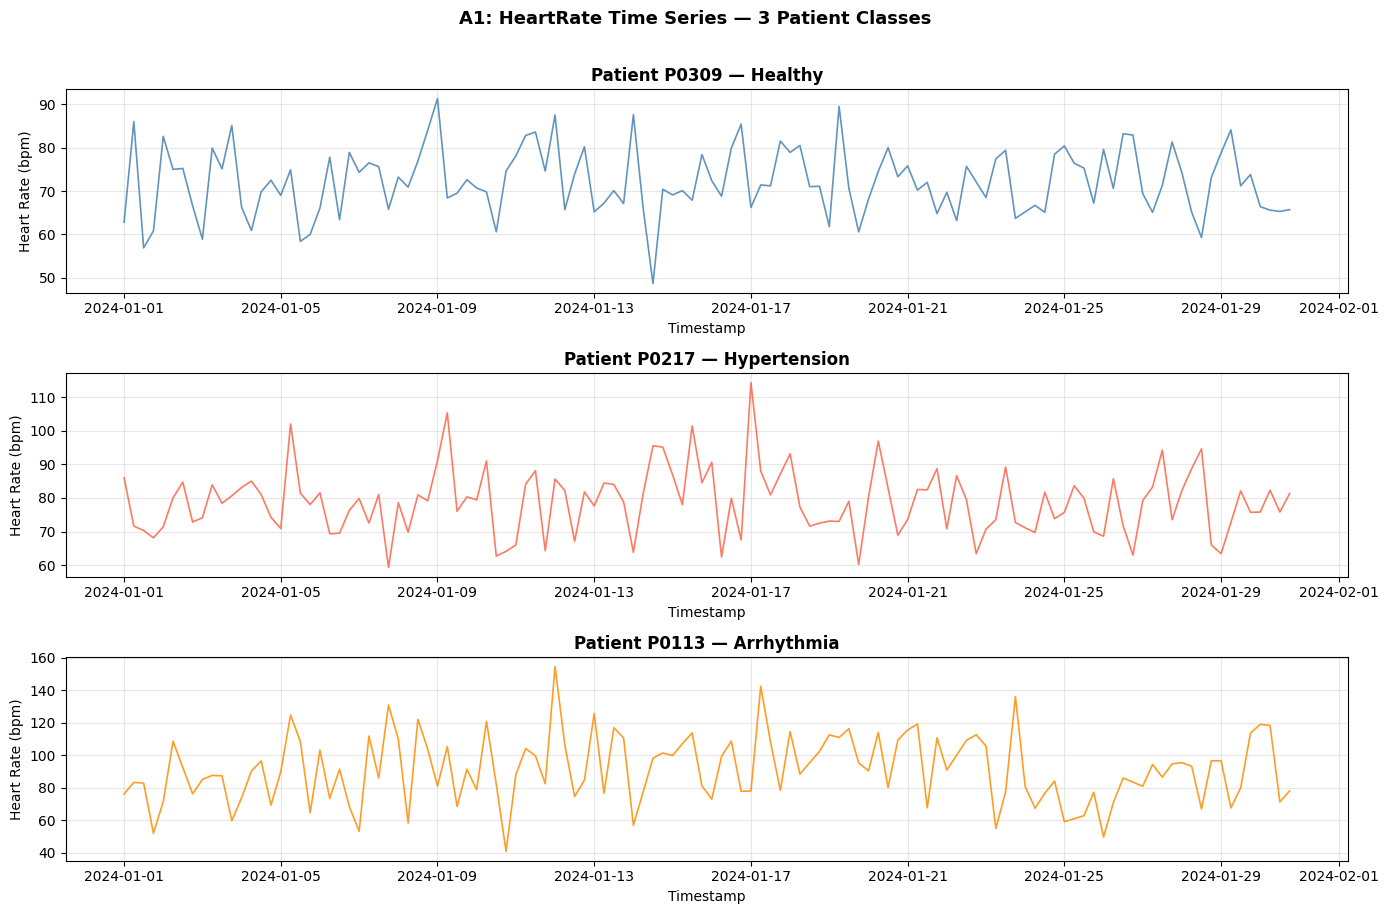

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
colors = {"Healthy": "steelblue", "Hypertension": "tomato", "Arrhythmia": "darkorange"}
 
for ax, (label, pid) in zip(axes, selected.items()):
    grp = patient_groups[pid]
    ax.plot(grp["Timestamp"], grp["HeartRate"], color=colors[label], linewidth=1.2, alpha=0.85)
    ax.set_title(f"Patient {pid} — {label}", fontweight="bold")
    ax.set_ylabel("Heart Rate (bpm)")
    ax.set_xlabel("Timestamp")
    ax.grid(True, alpha=0.3)
 
plt.suptitle("A1: HeartRate Time Series — 3 Patient Classes", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("A1_heartrate_timeseries.png", bbox_inches="tight")
plt.show()


**A1: Descriptive Statistics per patient**

In [10]:
print(f"{'Patient':<10} {'Class':<15} {'Mean':>7} {'Std':>7} {'Min':>7} {'Max':>7} {'CV%':>7}")
print("-"*60)
for label, pid in selected.items():
    hr = patient_groups[pid]["HeartRate"]
    mean, std, mn, mx = hr.mean(), hr.std(), hr.min(), hr.max()
    cv = std / mean * 100
    print(f"{pid:<10} {label:<15} {mean:>7.2f} {std:>7.2f} {mn:>7.2f} {mx:>7.2f} {cv:>7.2f}")
 


Patient    Class              Mean     Std     Min     Max     CV%
------------------------------------------------------------
P0309      Healthy           72.18    7.72   48.70   91.30   10.69
P0217      Hypertension      78.78    9.71   59.30  114.30   12.33
P0113      Arrhythmia        91.48   21.27   40.90  154.60   23.25


**A2: Rolling Mean on BloodPressureSystolic**

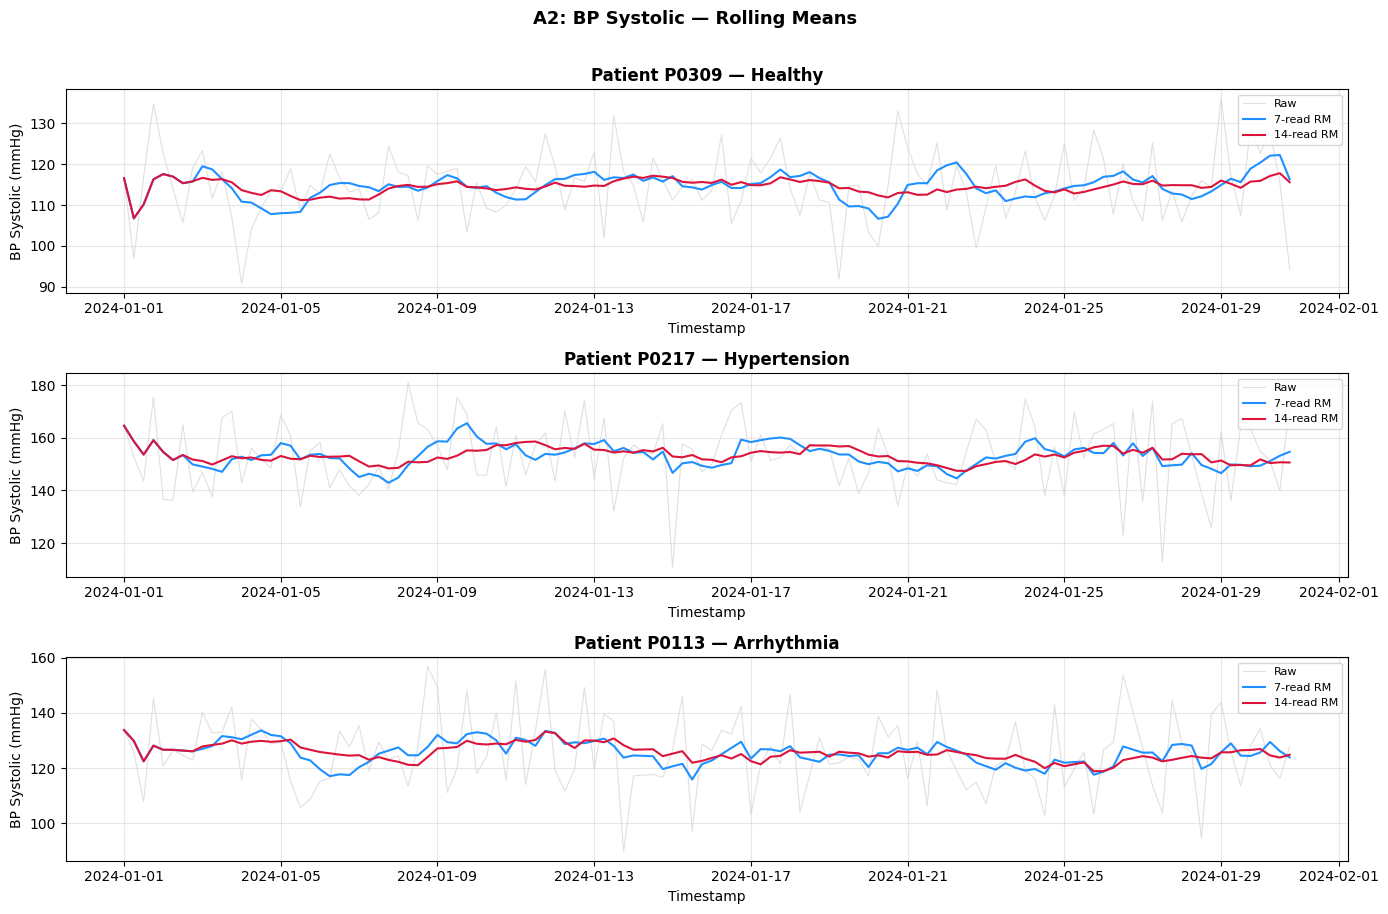

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, (label, pid) in zip(axes, selected.items()):
    grp = patient_groups[pid].reset_index(drop=True)
    bp = grp["BloodPressureSystolic"]
    ts = grp["Timestamp"]
    rm7  = bp.rolling(7,  min_periods=1).mean()
    rm14 = bp.rolling(14, min_periods=1).mean()
    ax.plot(ts, bp,   color="lightgray",   linewidth=0.8, label="Raw",          alpha=0.7)
    ax.plot(ts, rm7,  color="dodgerblue",  linewidth=1.5, label="7-read RM")
    ax.plot(ts, rm14, color="crimson",     linewidth=1.5, label="14-read RM")
    ax.set_title(f"Patient {pid} — {label}", fontweight="bold")
    ax.set_ylabel("BP Systolic (mmHg)")
    ax.set_xlabel("Timestamp")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.suptitle("A2: BP Systolic — Rolling Means", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("A2_rolling_means.png", bbox_inches="tight")
plt.show()


**A2: Seasonal Decomposition on longest patient sequence**

Longest patient: P0001 with 120 readings


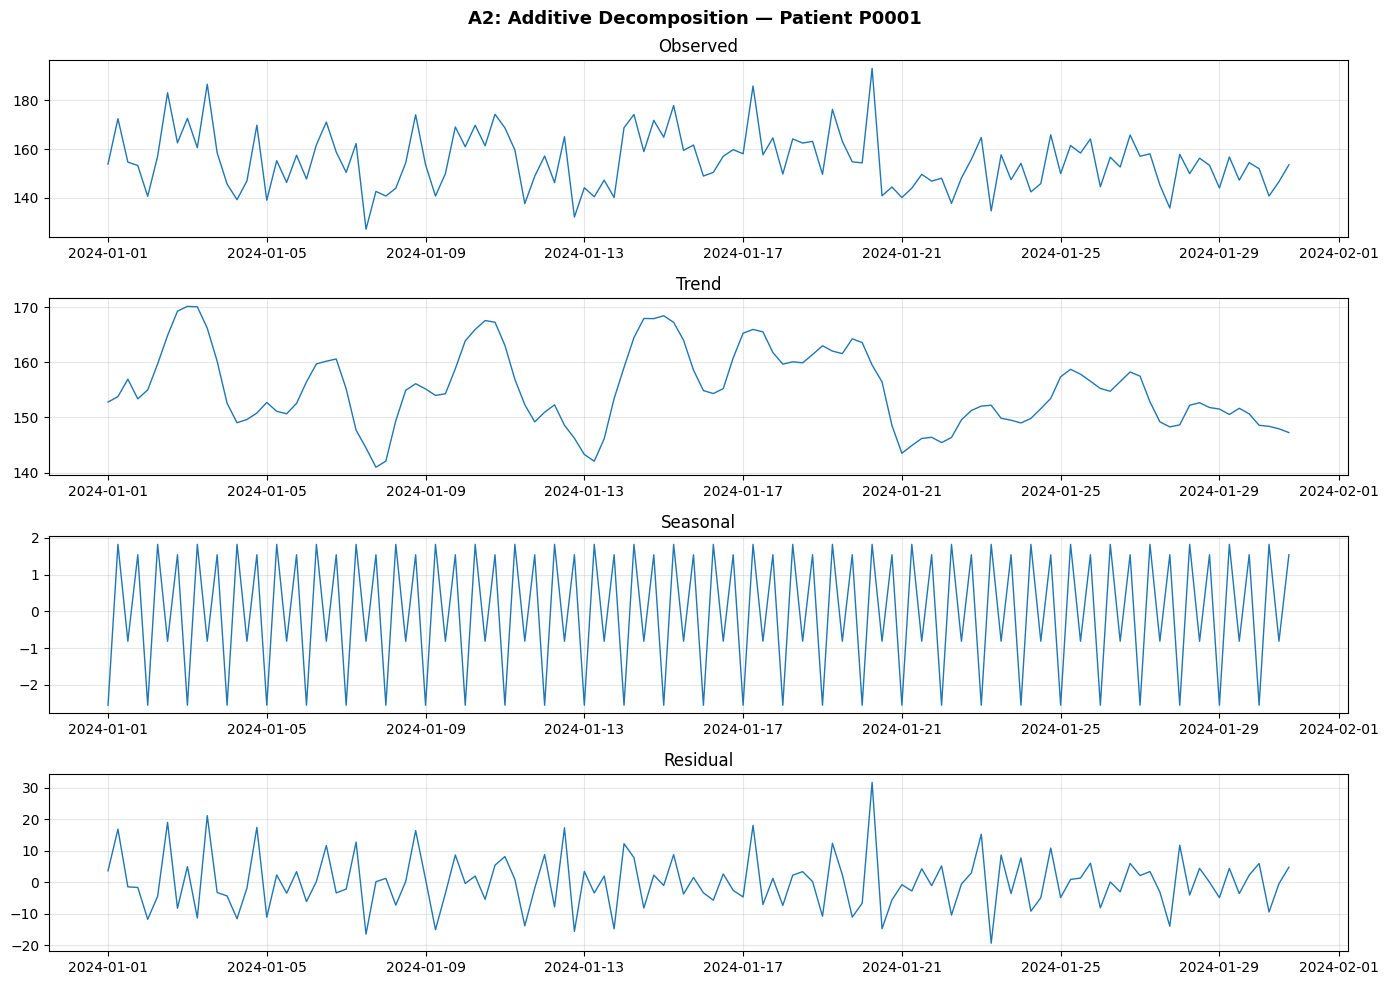


Trend direction : downward
Trend magnitude : -5.54 mmHg (first→last trend value)


In [12]:
longest_pid = df.groupby("PatientID").size().idxmax()
longest_grp = patient_groups[longest_pid].copy()
print(f"Longest patient: {longest_pid} with {len(longest_grp)} readings")
 
bp_series = longest_grp.set_index("Timestamp")["BloodPressureSystolic"].asfreq("6H", method="ffill")
 
decomp = seasonal_decompose(bp_series, model="additive", period=4, extrapolate_trend="freq")
 
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
for ax, data, title in zip(axes,
                            [bp_series, decomp.trend, decomp.seasonal, decomp.resid],
                            ["Observed", "Trend", "Seasonal", "Residual"]):
    ax.plot(data, linewidth=1.0)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
 
plt.suptitle(f"A2: Additive Decomposition — Patient {longest_pid}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("A2_decomposition.png", bbox_inches="tight")
plt.show()
 
trend_diff = decomp.trend.dropna()
direction = "upward" if trend_diff.iloc[-1] > trend_diff.iloc[0] else (
            "downward" if trend_diff.iloc[-1] < trend_diff.iloc[0] else "stable")
magnitude = trend_diff.iloc[-1] - trend_diff.iloc[0]
print(f"\nTrend direction : {direction}")
print(f"Trend magnitude : {magnitude:.2f} mmHg (first→last trend value)")


**A3: Anomaly Detection via μ ± 2σ**

In [13]:
anomaly_records = []
for pid, grp in patient_groups.items():
    hr = grp["HeartRate"]
    mu, sigma = hr.mean(), hr.std()
    mask = (hr < mu - 2*sigma) | (hr > mu + 2*sigma)
    anomaly_records.append({
        "PatientID": pid,
        "Diagnosis": grp["Diagnosis"].iloc[0],
        "TotalReadings": len(hr),
        "AnomalyCount": mask.sum(),
        "AnomalyPct": mask.sum() / len(hr) * 100
    })
 
anomaly_df = pd.DataFrame(anomaly_records)
 
total_anomalies = anomaly_df["AnomalyCount"].sum()
total_readings  = anomaly_df["TotalReadings"].sum()
print(f"Total anomalous readings: {total_anomalies} ({total_anomalies/total_readings*100:.2f}% of all readings)")
 
print("\nAnomaly % by Diagnosis class:")
class_anomaly = anomaly_df.groupby("Diagnosis").agg(
    TotalReadings=("TotalReadings","sum"),
    AnomalyCount=("AnomalyCount","sum")
)
class_anomaly["AnomalyPct"] = class_anomaly["AnomalyCount"] / class_anomaly["TotalReadings"] * 100
print(class_anomaly.to_string())


Total anomalous readings: 2629 (4.44% of all readings)

Anomaly % by Diagnosis class:
                TotalReadings  AnomalyCount  AnomalyPct
Diagnosis                                              
Arrhythmia               9260           379    4.092873
Diabetes                11015           494    4.484793
Healthy                 19551           887    4.536852
Hypertension            14748           653    4.427719
Sleep Disorder           4638           216    4.657180


**A3: Top 5 patients by anomaly count**

In [14]:
top5 = anomaly_df.sort_values("AnomalyCount", ascending=False).head(5)
print("\nTop 5 patients by anomaly count:")
print(top5[["PatientID","Diagnosis","AnomalyCount","AnomalyPct"]].to_string(index=False))



Top 5 patients by anomaly count:
PatientID    Diagnosis  AnomalyCount  AnomalyPct
    P0029     Diabetes             9    7.692308
    P0348      Healthy             9    7.500000
    P0344 Hypertension             9    7.500000
    P0427      Healthy             9    7.500000
    P0017 Hypertension             9    7.500000


**A3: Plot anomaly-heavy patient HeartRate**

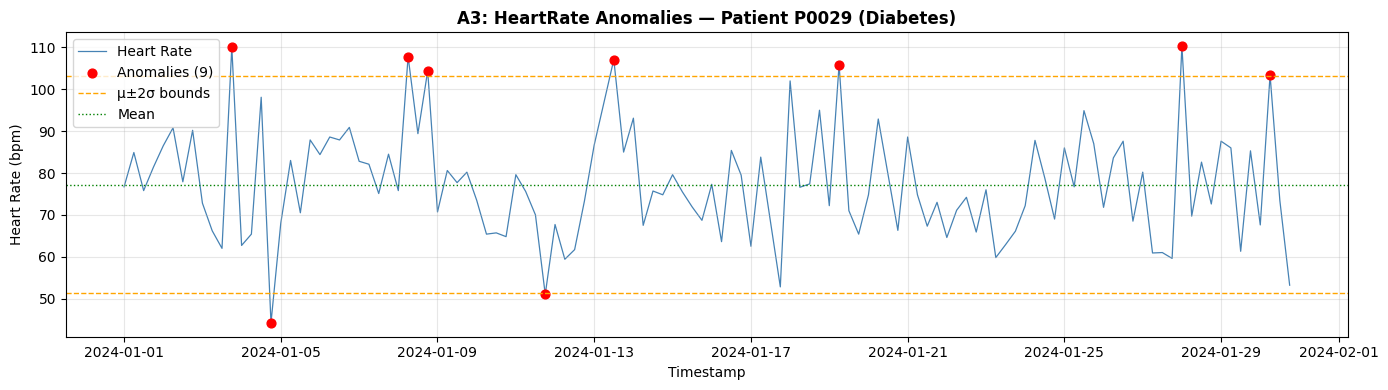


Arrhythmia anomaly rate : 4.09%
Healthy    anomaly rate : 4.54%
→ Arrhythmia > Healthy : False


In [15]:
heavy_pid = top5.iloc[0]["PatientID"]
heavy_grp = patient_groups[heavy_pid].copy()
hr = heavy_grp["HeartRate"]
mu, sigma = hr.mean(), hr.std()
mask = (hr < mu - 2*sigma) | (hr > mu + 2*sigma)
 
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(heavy_grp["Timestamp"], hr, color="steelblue", linewidth=0.9, label="Heart Rate", zorder=1)
ax.scatter(heavy_grp["Timestamp"][mask], hr[mask],
           color="red", s=40, zorder=2, label=f"Anomalies ({mask.sum()})")
ax.axhline(mu + 2*sigma, color="orange", linestyle="--", linewidth=1, label="μ±2σ bounds")
ax.axhline(mu - 2*sigma, color="orange", linestyle="--", linewidth=1)
ax.axhline(mu, color="green", linestyle=":", linewidth=1, label="Mean")
ax.set_title(f"A3: HeartRate Anomalies — Patient {heavy_pid} ({heavy_grp['Diagnosis'].iloc[0]})", fontweight="bold")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Heart Rate (bpm)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("A3_anomaly_plot.png", bbox_inches="tight")
plt.show()
 
# Compare Arrhythmia vs Healthy anomaly rates
arr_pct  = class_anomaly.loc["Arrhythmia",  "AnomalyPct"] if "Arrhythmia"  in class_anomaly.index else 0
heal_pct = class_anomaly.loc["Healthy",     "AnomalyPct"] if "Healthy"     in class_anomaly.index else 0
print(f"\nArrhythmia anomaly rate : {arr_pct:.2f}%")
print(f"Healthy    anomaly rate : {heal_pct:.2f}%")
print("→ Arrhythmia > Healthy :", arr_pct > heal_pct)


**PART B SIMILARITY SEARCH & PATIENT MATCHING**

**B Setup: Normalise feature matrix**


In [16]:
feature_cols = [c for c in feature_df.columns
                if c not in ["PatientID","Diagnosis","Age","Gender"]]
 
X_feat = feature_df[feature_cols].values
y_diag = feature_df["Diagnosis"].values
pids   = feature_df["PatientID"].values
 
scaler_b = StandardScaler()
X_scaled = scaler_b.fit_transform(X_feat)


**B1: Euclidean & Manhattan NN for 10 random query patients**

In [17]:
np.random.seed(42)
query_indices = np.random.choice(len(pids), 10, replace=False)
 
results_b1 = []
for qi in query_indices:
    qvec = X_scaled[qi]
    q_pid = pids[qi]
    candidates = np.array([i for i in range(len(pids)) if i != qi])
 
    # Euclidean
    euc_dists = np.linalg.norm(X_scaled[candidates] - qvec, axis=1)
    euc_top3  = candidates[np.argsort(euc_dists)[:3]]
 
    # Manhattan
    man_dists = np.sum(np.abs(X_scaled[candidates] - qvec), axis=1)
    man_top3  = candidates[np.argsort(man_dists)[:3]]
 
    row = {"Query": q_pid, "Query_Class": y_diag[qi]}
    for rank, (ei, mi) in enumerate(zip(euc_top3, man_top3), 1):
        row[f"Euc_NN{rank}"] = f"{pids[ei]} ({y_diag[ei]}, {np.linalg.norm(X_scaled[ei]-qvec):.3f})"
        row[f"Man_NN{rank}"] = f"{pids[mi]} ({y_diag[mi]}, {np.sum(np.abs(X_scaled[mi]-qvec)):.3f})"
    results_b1.append(row)
 
b1_df = pd.DataFrame(results_b1)
print("B1 — Nearest Neighbours (Euclidean vs Manhattan):")
pd.set_option("display.max_colwidth", 35)
print(b1_df.to_string(index=False))


B1 — Nearest Neighbours (Euclidean vs Manhattan):
Query    Query_Class                       Euc_NN1                        Man_NN1                       Euc_NN2                        Man_NN2                       Euc_NN3                        Man_NN3
P0362        Healthy        P0165 (Healthy, 1.881)         P0165 (Healthy, 7.764)        P0303 (Healthy, 2.086)         P0297 (Healthy, 8.725)        P0297 (Healthy, 2.209)         P0271 (Healthy, 8.886)
P0074        Healthy        P0135 (Healthy, 2.286)        P0082 (Healthy, 10.175)        P0082 (Healthy, 2.306)        P0402 (Healthy, 10.616)        P0045 (Healthy, 2.464)        P0135 (Healthy, 10.719)
P0375   Hypertension   P0457 (Hypertension, 3.592)   P0457 (Hypertension, 14.624)   P0405 (Hypertension, 3.769)   P0405 (Hypertension, 15.242)   P0094 (Hypertension, 3.822)   P0463 (Hypertension, 15.881)
P0156       Diabetes       P0400 (Diabetes, 4.460)       P0232 (Diabetes, 17.987)       P0232 (Diabetes, 4.604)       P0388 (Diabetes,

**B2: DTW-Based Similarity**

In [18]:
try:
    from dtaidistance import dtw as dtw_lib
    from dtaidistance import dtw_ndim
 
    # Patients with ≥ 20 readings
    valid_pids = [pid for pid, grp in patient_groups.items() if len(grp) >= 20]
    SEQ_LEN = 20
 
    seqs = []
    seq_pids = []
    seq_labels = []
    for pid in valid_pids:
        hr_seq = patient_groups[pid]["HeartRate"].values[:SEQ_LEN].astype(np.double)
        seqs.append(hr_seq)
        seq_pids.append(pid)
        seq_labels.append(patient_groups[pid]["Diagnosis"].iloc[0])
 
    seqs_arr = np.array(seqs)
 
    print(f"Computing DTW matrix for {len(seqs)} patients × 20-step HeartRate sequences...")
    dtw_matrix = dtw_lib.distance_matrix_fast(seqs_arr)
    dtw_matrix = np.array(dtw_matrix)
    np.fill_diagonal(dtw_matrix, np.inf)
    print("DTW matrix computed. Shape:", dtw_matrix.shape)
 
    # Pick 3 query patients: one per class
    def first_of_class(label):
        for i, l in enumerate(seq_labels):
            if l == label:
                return i
        return 0
 
    b2_queries = {
        "Healthy":      first_of_class("Healthy"),
        "Hypertension": first_of_class("Hypertension"),
        "Arrhythmia":   first_of_class("Arrhythmia"),
    }
 
    print("\nB2 — DTW Top-3 Nearest Neighbours:")
    for cls, qi in b2_queries.items():
        top3 = np.argsort(dtw_matrix[qi])[:3]
        print(f"  Query: {seq_pids[qi]} ({cls})")
        for rank, ni in enumerate(top3, 1):
            print(f"    NN{rank}: {seq_pids[ni]} ({seq_labels[ni]}) dist={dtw_matrix[qi,ni]:.3f}")
 
except ImportError:
    print("dtaidistance not installed. Run:  pip install dtaidistance")
    print("Fallback: using simple Euclidean on raw sequences.")
    dtw_matrix = None


Computing DTW matrix for 500 patients × 20-step HeartRate sequences...
DTW matrix computed. Shape: (500, 500)

B2 — DTW Top-3 Nearest Neighbours:
  Query: P0002 (Healthy)
    NN1: P0263 (Healthy) dist=20.566
    NN2: P0007 (Healthy) dist=20.983
    NN3: P0080 (Healthy) dist=21.147
  Query: P0001 (Hypertension)
    NN1: P0159 (Hypertension) dist=20.395
    NN2: P0374 (Hypertension) dist=21.042
    NN3: P0021 (Hypertension) dist=21.397
  Query: P0008 (Arrhythmia)
    NN1: P0178 (Arrhythmia) dist=68.964
    NN2: P0066 (Arrhythmia) dist=69.695
    NN3: P0211 (Arrhythmia) dist=72.102


**B3: Clinical Similarity  New Patient Query**


In [19]:
new_patient_known = {
    "HeartRate_mean":          98.0,
    "HeartRate_std":           18.0,
    "BloodPressureSystolic_mean": 155.0,
    "BloodPressureSystolic_std":  12.0,
    "BloodOxygenLevel_mean":   94.0,
    "SleepHours_mean":          4.5,
}
 

new_vec = []
for col in feature_cols:
    if col in new_patient_known:
        new_vec.append(new_patient_known[col])
    else:
        # Use training mean as imputation
        col_idx = list(feature_cols).index(col)
        new_vec.append(np.mean(X_feat[:, col_idx]))
 
new_vec = np.array(new_vec).reshape(1, -1)
new_vec_scaled = scaler_b.transform(new_vec)
 

euc_dists_new = np.linalg.norm(X_scaled - new_vec_scaled, axis=1)
top5_idx = np.argsort(euc_dists_new)[:5]
 
print("B3 — Top-5 Nearest Neighbours for New Patient:")
neighbour_classes = []
for rank, idx in enumerate(top5_idx, 1):
    print(f"  NN{rank}: {pids[idx]} | Class: {y_diag[idx]} | Distance: {euc_dists_new[idx]:.4f}")
    neighbour_classes.append(y_diag[idx])
 
from collections import Counter
vote_counts = Counter(neighbour_classes)
predicted_class = vote_counts.most_common(1)[0][0]
confidence = vote_counts[predicted_class] / 5
print(f"\nPredicted Diagnosis : {predicted_class}")
print(f"Confidence          : {confidence:.0%} ({vote_counts[predicted_class]}/5 neighbours)")


B3 — Top-5 Nearest Neighbours for New Patient:
  NN1: P0151 | Class: Diabetes | Distance: 5.4596
  NN2: P0037 | Class: Diabetes | Distance: 5.5702
  NN3: P0232 | Class: Diabetes | Distance: 5.7650
  NN4: P0490 | Class: Diabetes | Distance: 5.8939
  NN5: P0413 | Class: Diabetes | Distance: 5.8947

Predicted Diagnosis : Diabetes
Confidence          : 100% (5/5 neighbours)


**SUPERVISED CLASSIFICATION**

**Setup: Train-Test Split**

In [20]:
X = X_scaled.copy()
y = y_diag.copy()
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
 
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print("Class distribution in test set:")
for cls, cnt in Counter(y_test).items():
    print(f"  {cls}: {cnt}")
 
# Helper — print full evaluation report
def evaluate(name, model, X_tr, y_tr, X_te, y_te, label_names=None):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_te, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_te, y_pred, average="macro", zero_division=0)
    print(f"\n{'='*55}")
    print(f"{name} — Evaluation on Test Set")
    print(f"{'='*55}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Recall    (macro): {rec:.4f}")
    print(f"F1-score  (macro): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(7,5))
    cm = confusion_matrix(y_te, y_pred, labels=label_names)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"CM_{name.replace(' ','_')}.png", bbox_inches="tight")
    plt.show()
    return {"Model": name, "Accuracy": acc, "Macro Precision": prec,
            "Macro Recall": rec, "Macro F1": f1}
 
classes = sorted(np.unique(y))
summary_table = []


Train size: 400 | Test size: 100
Class distribution in test set:
  Healthy: 33
  Arrhythmia: 16
  Diabetes: 19
  Hypertension: 24
  Sleep Disorder: 8


**Decision Tree  Depth Tuning**

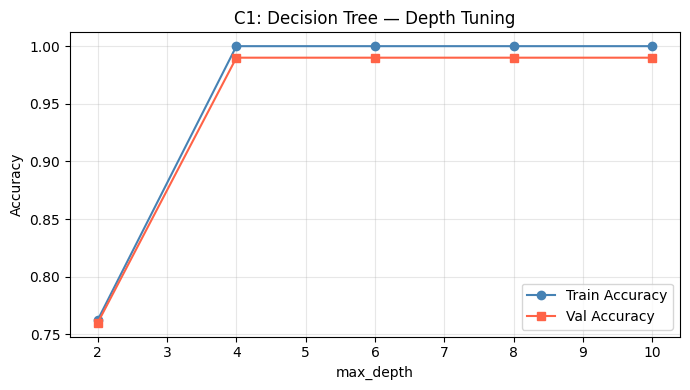

Best depth: 4 | Val Accuracy: 0.9900


In [21]:
depths = [2, 4, 6, 8, 10]
train_accs, val_accs = [], []
for d in depths:
    dt = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    val_accs.append(accuracy_score(y_test,  dt.predict(X_test)))
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, train_accs, "o-", label="Train Accuracy", color="steelblue")
ax.plot(depths, val_accs,   "s-", label="Val Accuracy",   color="tomato")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("C1: Decision Tree — Depth Tuning")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("C1_depth_tuning.png", bbox_inches="tight")
plt.show()
 
best_depth = depths[np.argmax(val_accs)]
print(f"Best depth: {best_depth} | Val Accuracy: {max(val_accs):.4f}")


**C1: Train Decision Tree at best depth + visualise**


Decision Tree — Evaluation on Test Set
Accuracy : 0.9900
Precision (macro): 0.9882
Recall    (macro): 0.9750
F1-score  (macro): 0.9806

Classification Report:
                precision    recall  f1-score   support

    Arrhythmia       0.94      1.00      0.97        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      0.88      0.93         8

      accuracy                           0.99       100
     macro avg       0.99      0.97      0.98       100
  weighted avg       0.99      0.99      0.99       100



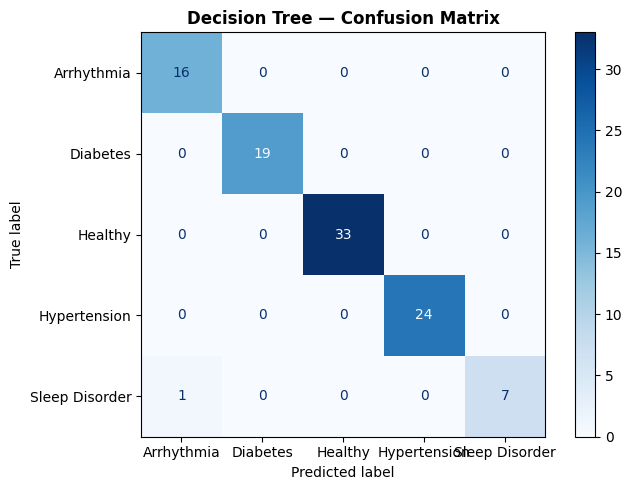

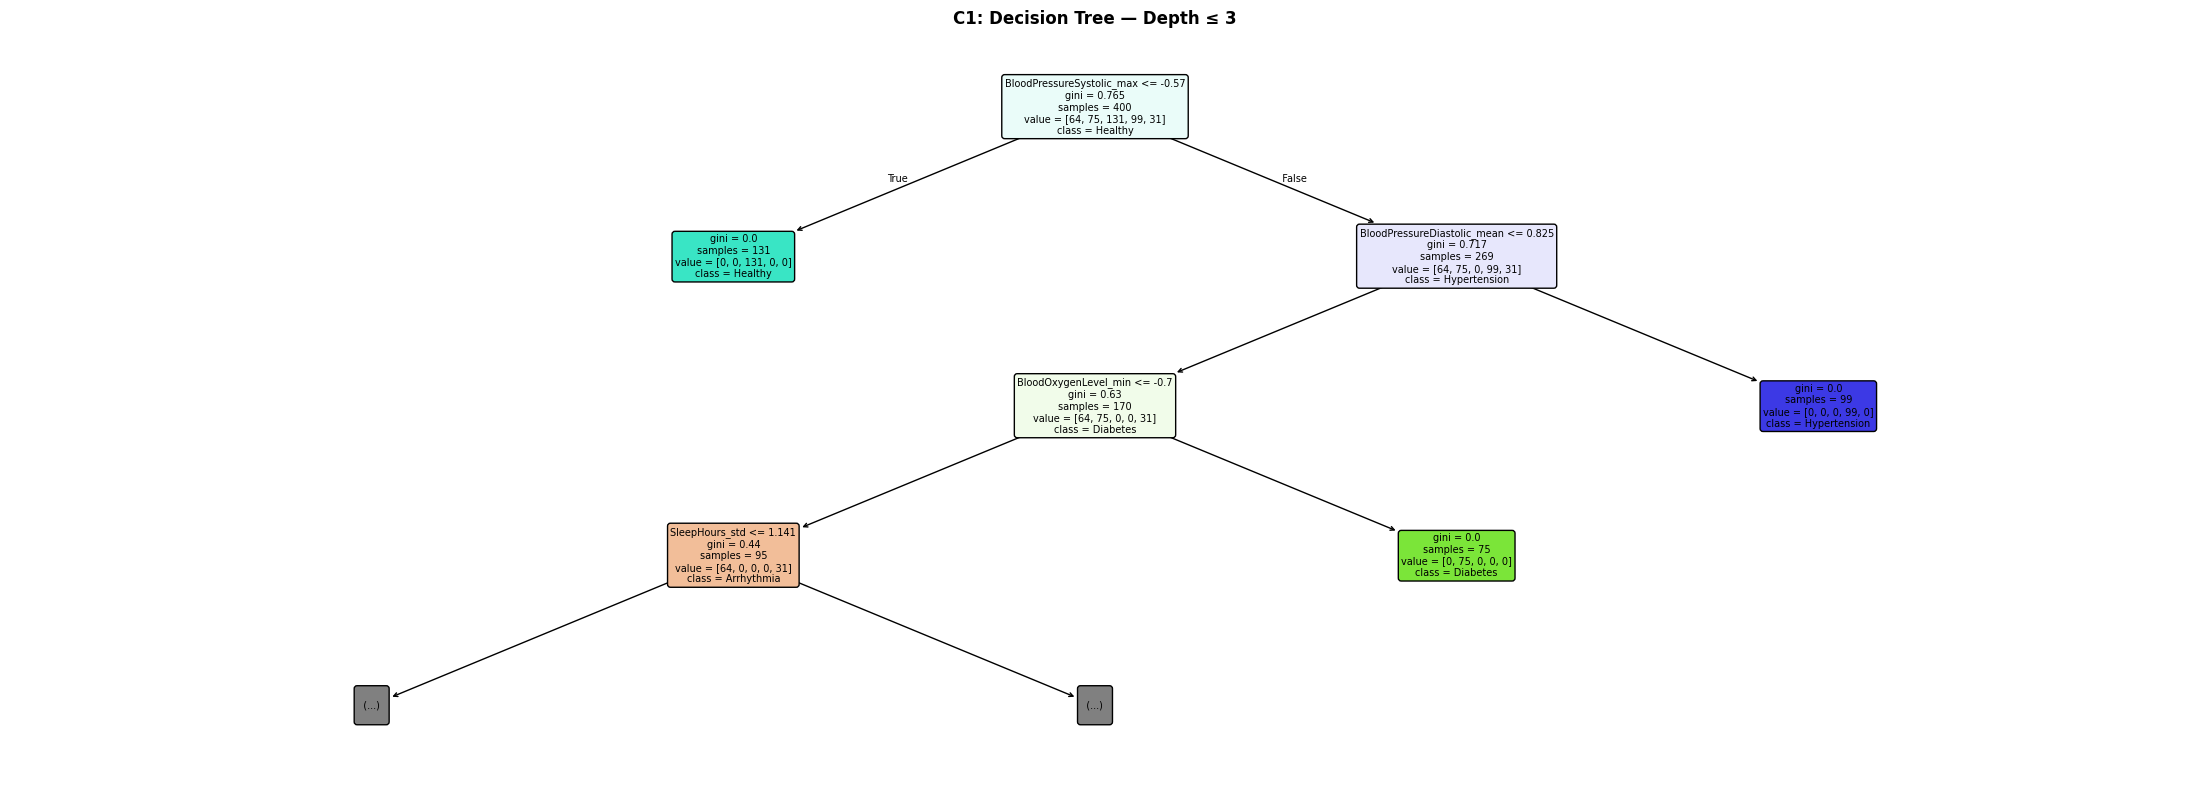


Top 5 Features by Gini Importance:
  1. BloodPressureSystolic_max           0.3695
  2. BloodPressureDiastolic_mean         0.2801
  3. BloodOxygenLevel_min                0.2138
  4. SleepHours_std                      0.1365
  5. StressLevel_slope                   0.0000


In [22]:
dt_best = DecisionTreeClassifier(criterion="gini", max_depth=best_depth, random_state=42)
result_c1 = evaluate("Decision Tree", dt_best, X_train, y_train, X_test, y_test, classes)
summary_table.append(result_c1)
 
# Plot tree (up to depth 3)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_best, max_depth=3, feature_names=feature_cols,
          class_names=classes, filled=True, rounded=True,
          fontsize=7, ax=ax)
ax.set_title("C1: Decision Tree — Depth ≤ 3", fontweight="bold")
plt.tight_layout()
plt.savefig("C1_tree_plot.png", bbox_inches="tight")
plt.show()
 
# Feature importances
importances = dt_best.feature_importances_
top5_feat_idx = np.argsort(importances)[::-1][:5]
print("\nTop 5 Features by Gini Importance:")
for rank, idx in enumerate(top5_feat_idx, 1):
    print(f"  {rank}. {feature_cols[idx]:<35} {importances[idx]:.4f}")


**C2: Rule-Based Classification (extracted from Decision Tree)**

C2 — Rule Set (top 10 by coverage):

RULE 1:
  IF   BloodPressureSystolic_max <= -0.570
  THEN Diagnosis = Healthy
       (coverage: 0.2%, accuracy: 100.0%)

RULE 2:
  IF   BloodPressureSystolic_max > -0.570 AND BloodPressureDiastolic_mean <= 0.825 AND BloodOxygenLevel_min <= -0.700 AND SleepHours_std <= 1.141
  THEN Diagnosis = Arrhythmia
       (coverage: 0.2%, accuracy: 100.0%)

RULE 3:
  IF   BloodPressureSystolic_max > -0.570 AND BloodPressureDiastolic_mean <= 0.825 AND BloodOxygenLevel_min <= -0.700 AND SleepHours_std > 1.141
  THEN Diagnosis = Sleep Disorder
       (coverage: 0.2%, accuracy: 100.0%)

RULE 4:
  IF   BloodPressureSystolic_max > -0.570 AND BloodPressureDiastolic_mean <= 0.825 AND BloodOxygenLevel_min > -0.700
  THEN Diagnosis = Diabetes
       (coverage: 0.2%, accuracy: 100.0%)

RULE 5:
  IF   BloodPressureSystolic_max > -0.570 AND BloodPressureDiastolic_mean > 0.825
  THEN Diagnosis = Hypertension
       (coverage: 0.2%, accuracy: 100.0%)


Best discriminating rul

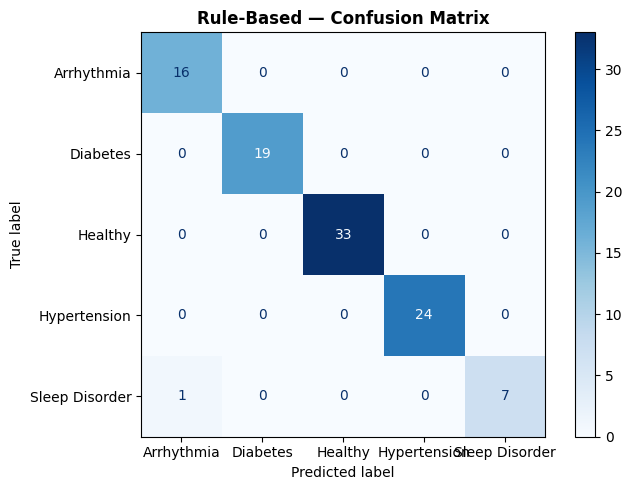

In [23]:
from sklearn.tree import _tree
 
def extract_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    rules = []
 
    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node],  path + [f"{name} <= {threshold:.3f}"])
            recurse(tree_.children_right[node], path + [f"{name} > {threshold:.3f}"])
        else:
            values = tree_.value[node][0]
            predicted_class = class_names[np.argmax(values)]
            total_samples = int(values.sum())
            correct = int(np.max(values))
            coverage_pct = total_samples / tree_.n_node_samples[0] * 100
            accuracy_pct = correct / total_samples * 100 if total_samples > 0 else 0
            rules.append({
                "conditions": " AND ".join(path) if path else "TRUE",
                "class": predicted_class,
                "coverage_pct": coverage_pct,
                "accuracy_pct": accuracy_pct,
                "n_samples": total_samples
            })
 
    recurse(0, [])
    return rules
 
rules = extract_rules(dt_best, feature_cols, classes)
rules_df = pd.DataFrame(rules).sort_values("n_samples", ascending=False)
 
print("C2 — Rule Set (top 10 by coverage):\n")
for i, row in rules_df.head(10).iterrows():
    print(f"RULE {i+1}:")
    print(f"  IF   {row['conditions']}")
    print(f"  THEN Diagnosis = {row['class']}")
    print(f"       (coverage: {row['coverage_pct']:.1f}%, accuracy: {row['accuracy_pct']:.1f}%)\n")
 
# Best rule per class
print("\nBest discriminating rule per class:")
for cls in classes:
    cls_rules = rules_df[rules_df["class"] == cls]
    if len(cls_rules) > 0:
        best = cls_rules.sort_values("accuracy_pct", ascending=False).iloc[0]
        print(f"\n  [{cls}]")
        print(f"  IF {best['conditions']}")
        print(f"  → accuracy: {best['accuracy_pct']:.1f}%, coverage: {best['coverage_pct']:.1f}%")
 
# Apply rule set = same as DT predictions since rules are extracted from DT
result_c2 = evaluate("Rule-Based", dt_best, X_train, y_train, X_test, y_test, classes)
result_c2["Model"] = "Rule-Based"
summary_table.append(result_c2)


**C3: kNN  Tune k**

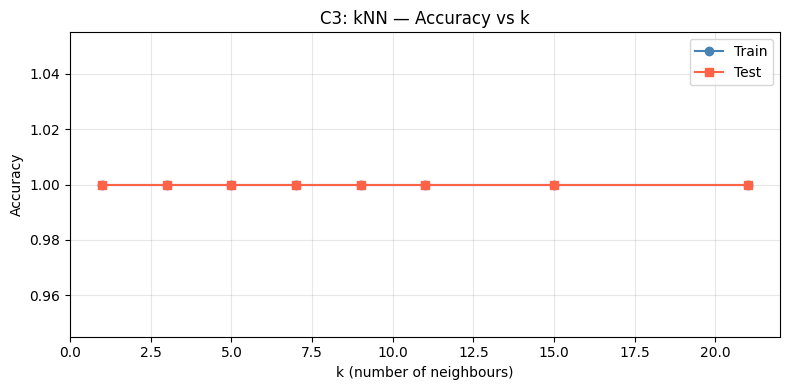

Best k: 1 | Test Accuracy: 1.0000


In [24]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_train_accs, knn_test_accs = [], []
 
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train, y_train)
    knn_train_accs.append(accuracy_score(y_train, knn.predict(X_train)))
    knn_test_accs.append( accuracy_score(y_test,  knn.predict(X_test)))
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, knn_train_accs, "o-", label="Train", color="steelblue")
ax.plot(k_values, knn_test_accs,  "s-", label="Test",  color="tomato")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Accuracy")
ax.set_title("C3: kNN — Accuracy vs k")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("C3_knn_tuning.png", bbox_inches="tight")
plt.show()
 
best_k = k_values[np.argmax(knn_test_accs)]
print(f"Best k: {best_k} | Test Accuracy: {max(knn_test_accs):.4f}")


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

**C3: kNN  Euclidean vs Manhattan comparison**

kNN (k=1,  euclidean): Accuracy = 1.0000
kNN (k=1,  manhattan): Accuracy = 1.0000

kNN — Evaluation on Test Set
Accuracy : 1.0000
Precision (macro): 1.0000
Recall    (macro): 1.0000
F1-score  (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00         8

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



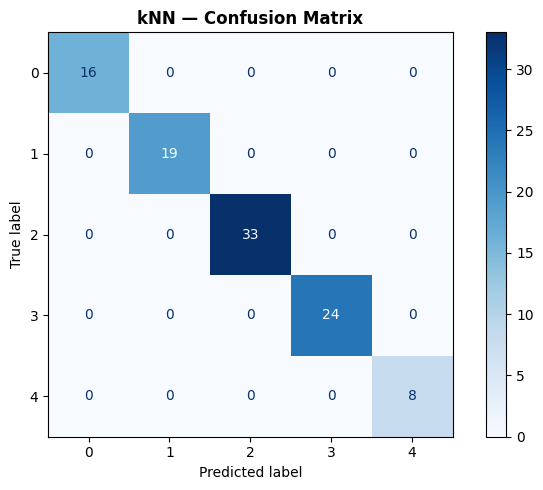

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


classes = le.classes_



for metric in ["euclidean", "manhattan"]:
    
    knn_m = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )
    
    knn_m.fit(X_train, y_train_encoded)
    
    acc_m = accuracy_score(
        y_test_encoded,
        knn_m.predict(X_test)
    )
    
    print(f"kNN (k={best_k}, {metric:>10}): Accuracy = {acc_m:.4f}")



knn_best = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean"
)


# Step 4: Evaluate model
result_c3 = evaluate(
    "kNN",
    knn_best,
    X_train,
    y_train_encoded,
    X_test,
    y_test_encoded,
    classes
)



summary_table.append(result_c3)

**C4: Naïve Bayes Gaussian Assumption Check**

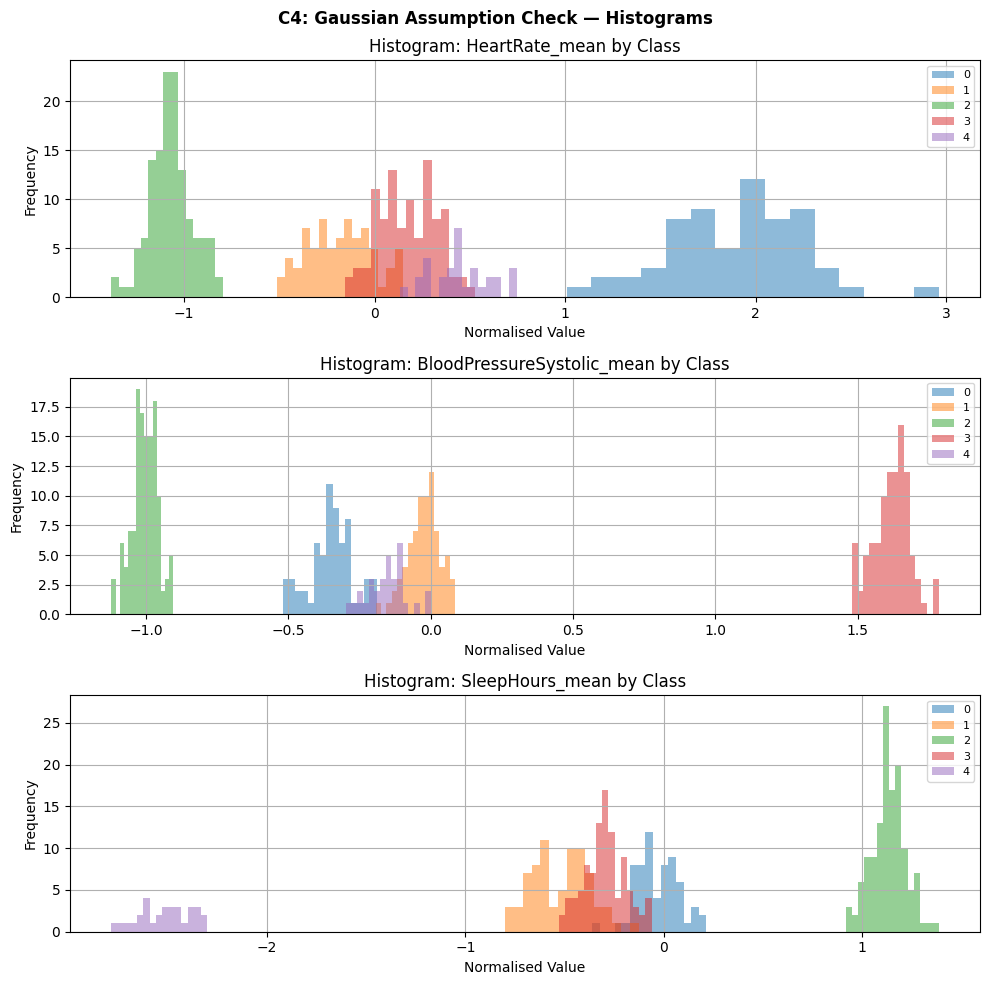

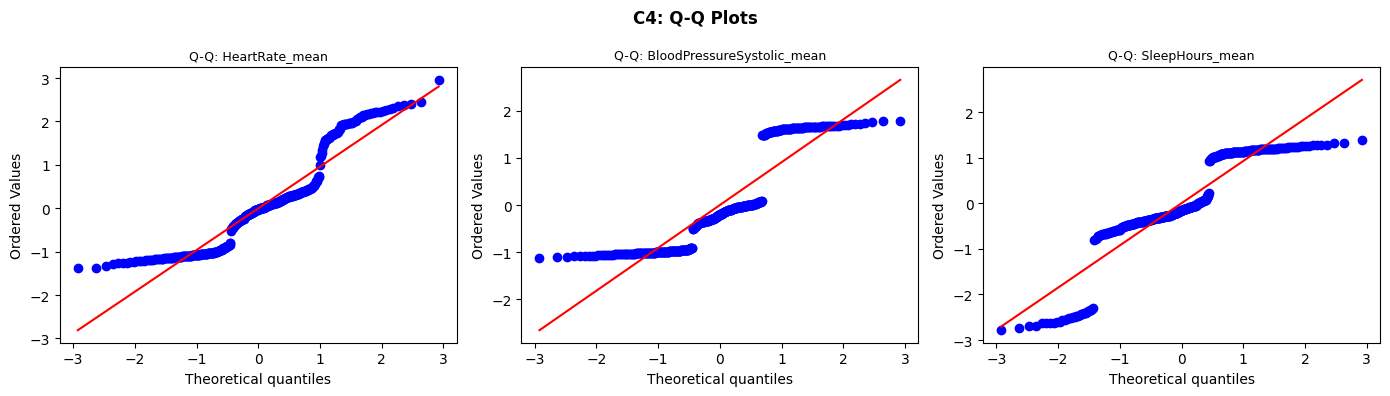

In [27]:
check_cols = ["HeartRate_mean", "BloodPressureSystolic_mean", "SleepHours_mean"]
feat_df_with_label = pd.DataFrame(X_train, columns=feature_cols)
feat_df_with_label["Diagnosis"] = y_train
 
fig, axes = plt.subplots(len(check_cols), 1, figsize=(10, 10))
for ax, col in zip(axes, check_cols):
    for cls in classes:
        subset = feat_df_with_label[feat_df_with_label["Diagnosis"] == cls][col]
        subset.hist(ax=ax, alpha=0.5, bins=15, label=cls)
    ax.set_title(f"Histogram: {col} by Class")
    ax.set_xlabel("Normalised Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
 
plt.suptitle("C4: Gaussian Assumption Check — Histograms", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("C4_histograms.png", bbox_inches="tight")
plt.show()
 
# Q-Q plots
fig, axes = plt.subplots(1, len(check_cols), figsize=(14, 4))
for ax, col in zip(axes, check_cols):
    col_idx = list(feature_cols).index(col)
    stats.probplot(X_train[:, col_idx], dist="norm", plot=ax)
    ax.set_title(f"Q-Q: {col}", fontsize=9)
 
plt.suptitle("C4: Q-Q Plots", fontweight="bold")
plt.tight_layout()
plt.savefig("C4_qq_plots.png", bbox_inches="tight")
plt.show()


**C4: Naïve Bayes Training + Pearson Correlation**


Naïve Bayes — Evaluation on Test Set
Accuracy : 1.0000
Precision (macro): 1.0000
Recall    (macro): 1.0000
F1-score  (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00         8

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



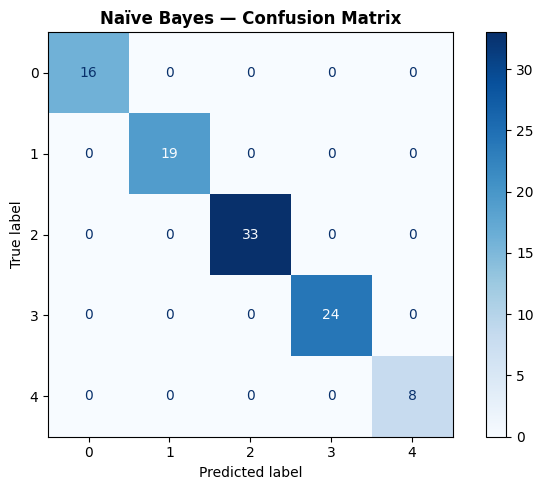

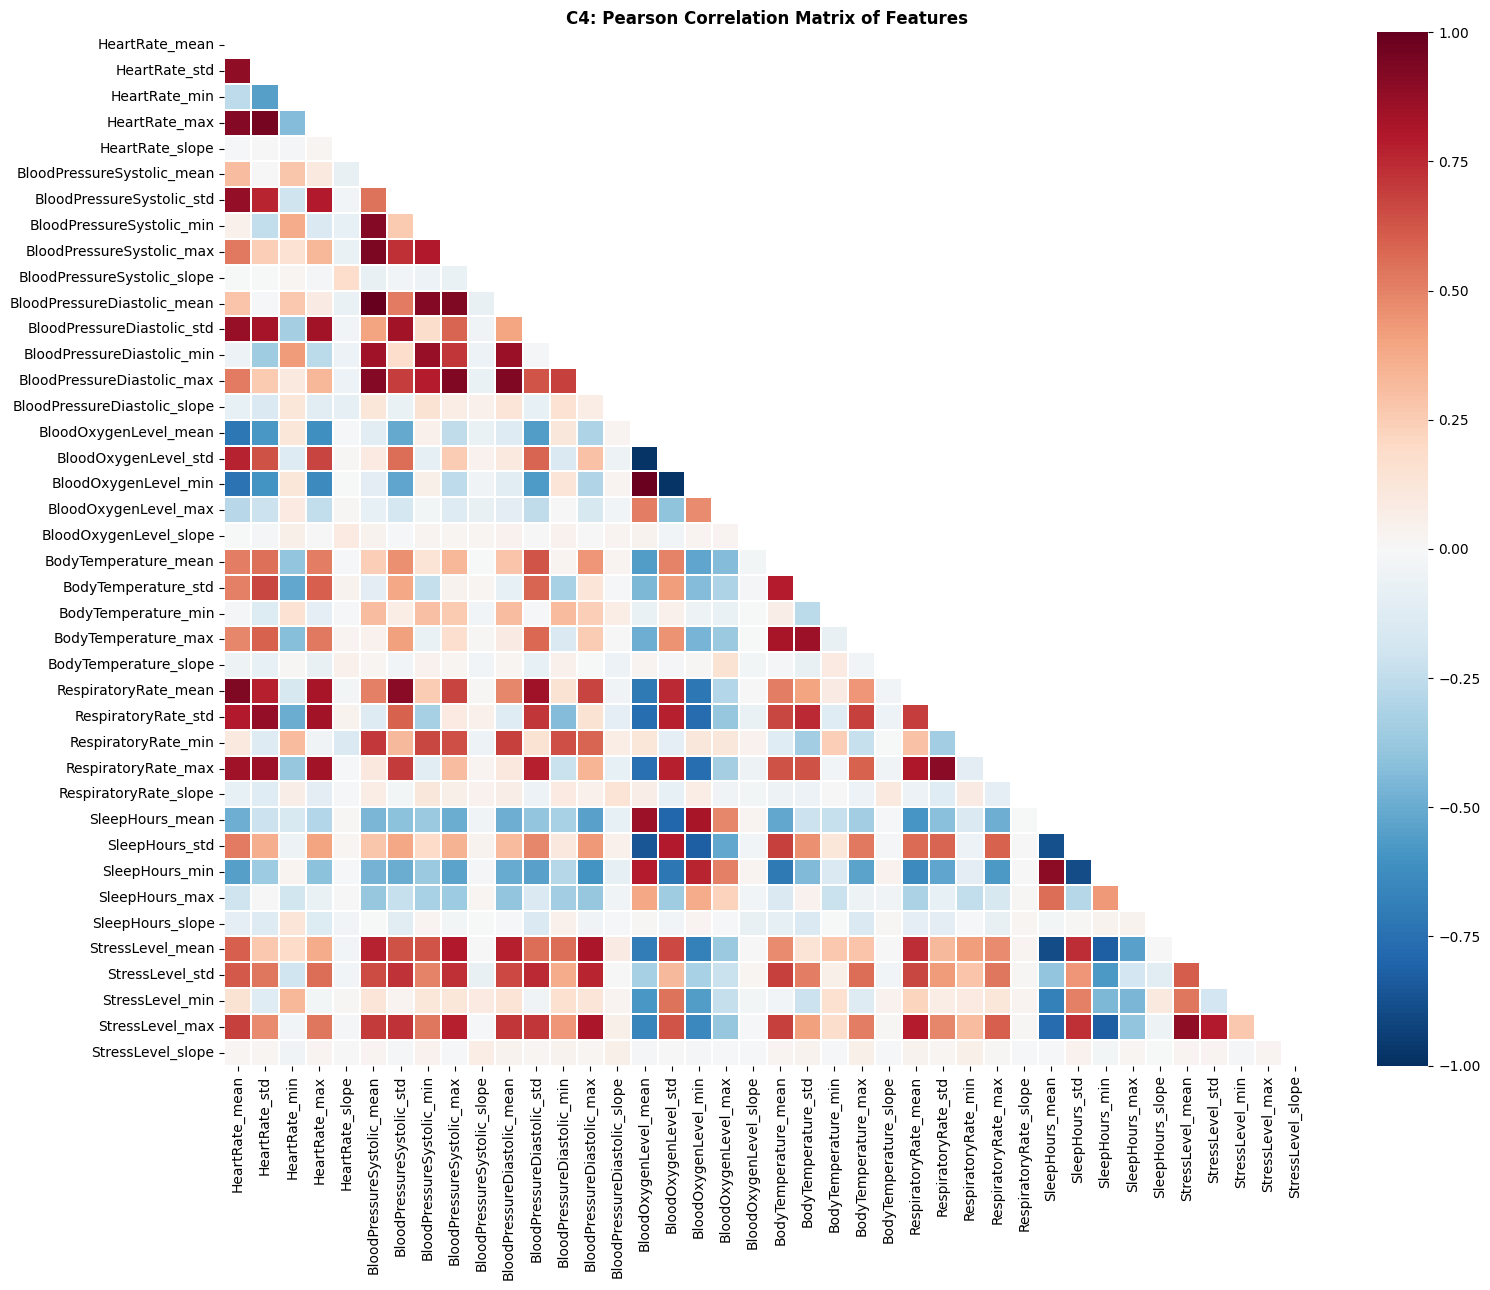


Top 2 most correlated feature pairs:
  1. BloodPressureSystolic_mean ↔ BloodPressureDiastolic_mean  r = 0.9925
  2. BloodOxygenLevel_mean ↔ BloodOxygenLevel_min  r = 0.9859


In [28]:
gnb = GaussianNB()
result_c4 = evaluate("Naïve Bayes", gnb, X_train, y_train, X_test, y_test, classes)
summary_table.append(result_c4)
 
# Pearson correlation heatmap
corr_matrix = pd.DataFrame(X_train, columns=feature_cols).corr()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, annot=False, ax=ax, linewidths=0.3)
ax.set_title("C4: Pearson Correlation Matrix of Features", fontweight="bold")
plt.tight_layout()
plt.savefig("C4_correlation_heatmap.png", bbox_inches="tight")
plt.show()
 
# Find top 2 most correlated pairs
corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        corr_pairs.append((abs(r), feature_cols[i], feature_cols[j], r))
corr_pairs.sort(key=lambda x: x[0], reverse=True)
print("\nTop 2 most correlated feature pairs:")
for rank, (absR, f1, f2, r) in enumerate(corr_pairs[:2], 1):
    print(f"  {rank}. {f1} ↔ {f2}  r = {r:.4f}")


**C5: SVM  Kernel and C tuning**

In [29]:
C_values = [0.1, 1, 10, 100]
kernels = {"RBF": "rbf", "Polynomial (d=3)": "poly"}
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_results = {}
 
for kname, kval in kernels.items():
    cv_scores = []
    for C in C_values:
        kwargs = dict(kernel=kval, C=C, random_state=42, decision_function_shape="ovr")
        if kval == "poly":
            kwargs["degree"] = 3
        svc = SVC(**kwargs)
        scores = cross_val_score(svc, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
        cv_scores.append(scores.mean())
        print(f"  {kname}, C={C:<5}: CV Accuracy = {scores.mean():.4f} ± {scores.std():.4f}")
    best_idx = np.argmax(cv_scores)
    svm_results[kname] = {"C": C_values[best_idx], "cv_acc": cv_scores[best_idx]}
    print(f"  → Best C for {kname}: {C_values[best_idx]}\n")


  RBF, C=0.1  : CV Accuracy = 0.9975 ± 0.0050
  RBF, C=1    : CV Accuracy = 1.0000 ± 0.0000
  RBF, C=10   : CV Accuracy = 1.0000 ± 0.0000
  RBF, C=100  : CV Accuracy = 1.0000 ± 0.0000
  → Best C for RBF: 1

  Polynomial (d=3), C=0.1  : CV Accuracy = 0.9975 ± 0.0050
  Polynomial (d=3), C=1    : CV Accuracy = 1.0000 ± 0.0000
  Polynomial (d=3), C=10   : CV Accuracy = 1.0000 ± 0.0000
  Polynomial (d=3), C=100  : CV Accuracy = 1.0000 ± 0.0000
  → Best C for Polynomial (d=3): 1



**C5: Train final SVM with best kernel & C**

Best kernel: RBF, Best C: 1

SVM (RBF) — Evaluation on Test Set
Accuracy : 1.0000
Precision (macro): 1.0000
Recall    (macro): 1.0000
F1-score  (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00         8

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



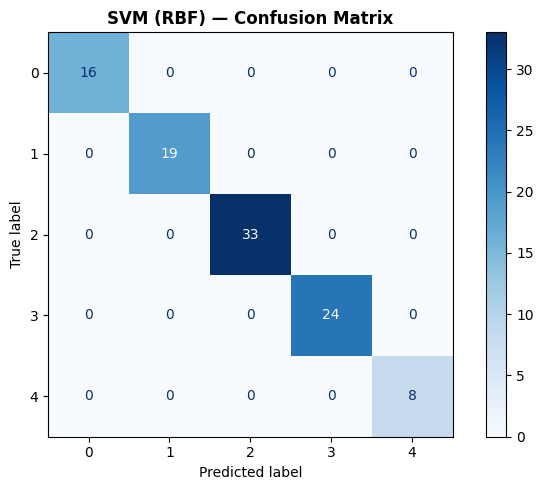

In [30]:
best_kernel_name = max(svm_results, key=lambda k: svm_results[k]["cv_acc"])
best_C_svm       = svm_results[best_kernel_name]["C"]
best_kernel_val  = kernels[best_kernel_name]
print(f"Best kernel: {best_kernel_name}, Best C: {best_C_svm}")
 
svm_kwargs = dict(kernel=best_kernel_val, C=best_C_svm,
                  random_state=42, decision_function_shape="ovr", probability=True)
if best_kernel_val == "poly":
    svm_kwargs["degree"] = 3
 
svm_final = SVC(**svm_kwargs)
result_c5 = evaluate(f"SVM ({best_kernel_name})", svm_final, X_train, y_train, X_test, y_test, classes)
result_c5["Model"] = "SVM"
summary_table.append(result_c5)


**C5: Decision Boundary via PCA (2D)**

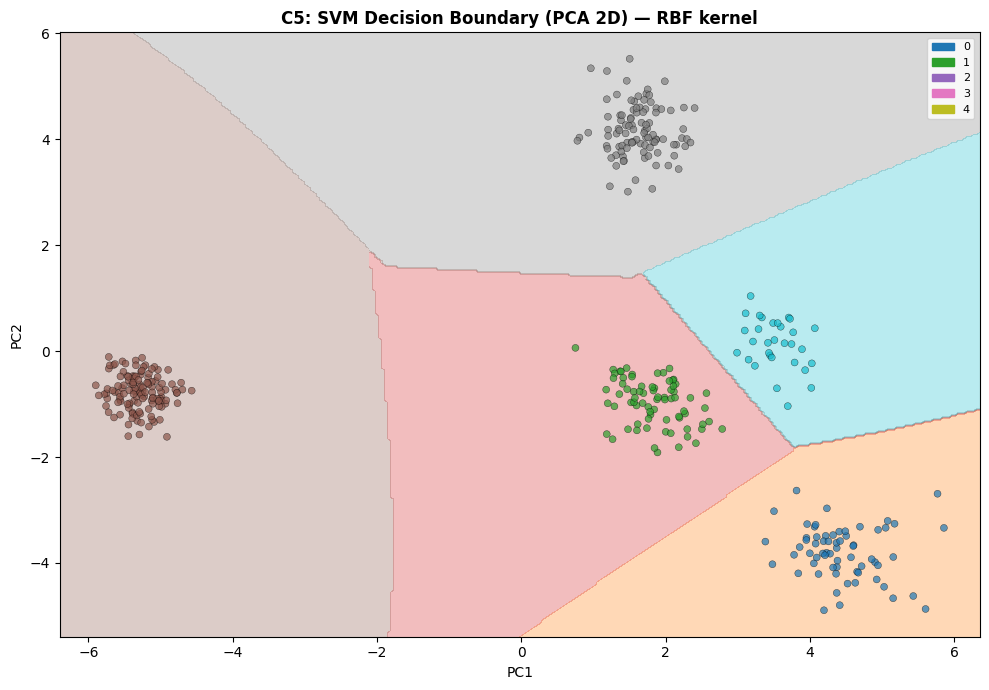

In [31]:
from sklearn.decomposition import PCA
 
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)
 
svm_2d = SVC(kernel=best_kernel_val, C=best_C_svm, random_state=42,
             decision_function_shape="ovr")
if best_kernel_val == "poly":
    svm_2d.set_params(degree=3)
svm_2d.fit(X_train_2d, y_train)
 
# Mesh grid
x_min, x_max = X_train_2d[:,0].min()-0.5, X_train_2d[:,0].max()+0.5
y_min, y_max = X_train_2d[:,1].min()-0.5, X_train_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
 
le = LabelEncoder()
le.fit(classes)
Z_enc = le.transform(Z).reshape(xx.shape)
 
fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z_enc, alpha=0.3, cmap="tab10",
            levels=np.arange(-0.5, len(classes)+0.5))
scatter_colors = plt.cm.tab10(le.transform(y_train) / len(classes))
ax.scatter(X_train_2d[:,0], X_train_2d[:,1], c=le.transform(y_train),
           cmap="tab10", edgecolors="k", linewidths=0.3, s=25, alpha=0.7)
ax.set_title(f"C5: SVM Decision Boundary (PCA 2D) — {best_kernel_name} kernel", fontweight="bold")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
patches = [mpatches.Patch(color=plt.cm.tab10(i/len(classes)), label=cls)
           for i, cls in enumerate(classes)]
ax.legend(handles=patches, fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("C5_decision_boundary.png", bbox_inches="tight")
plt.show()


**FINAL SUMMARY TABLE (C1–C5)**


CLASSIFIER COMPARISON SUMMARY
   Classifier Accuracy Macro Precision Macro Recall Macro F1
Decision Tree   0.9900          0.9882       0.9750   0.9806
   Rule-Based   0.9900          0.9882       0.9750   0.9806
          kNN   1.0000          1.0000       1.0000   1.0000
  Naïve Bayes   1.0000          1.0000       1.0000   1.0000
          SVM   1.0000          1.0000       1.0000   1.0000


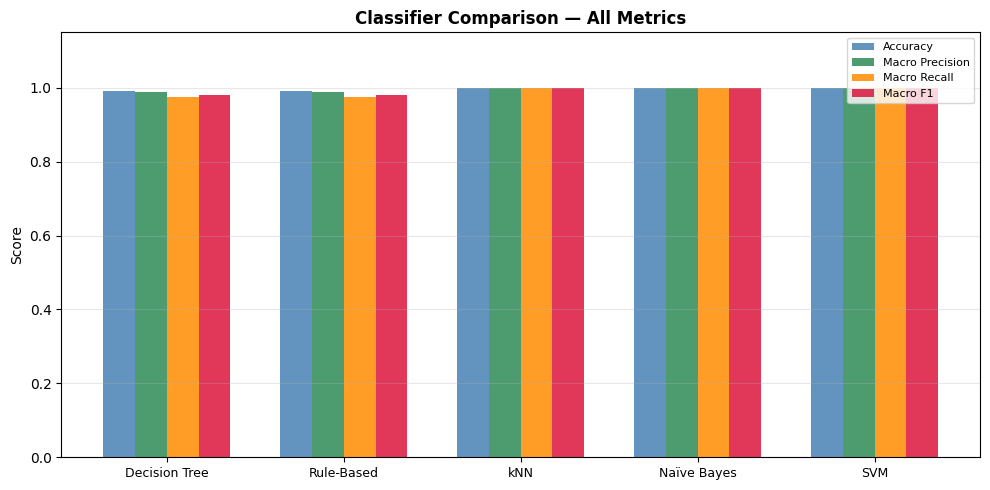

In [32]:
summary_df = pd.DataFrame(summary_table)
summary_df.columns = ["Classifier", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
 
for col in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]:
    summary_df[col] = summary_df[col].apply(lambda x: f"{x:.4f}")
 
print("\n" + "="*70)
print("CLASSIFIER COMPARISON SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
 
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
x = np.arange(len(summary_df))
width = 0.18
colors_bar = ["steelblue","seagreen","darkorange","crimson"]
raw = pd.DataFrame(summary_table)
for i, (m, color) in enumerate(zip(["Accuracy","Macro Precision","Macro Recall","Macro F1"], colors_bar)):
    ax.bar(x + i*width, raw[m], width, label=m, color=color, alpha=0.85)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(raw["Model"], fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Classifier Comparison — All Metrics", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("C_summary_comparison.png", bbox_inches="tight")
plt.show()

